<a href="https://colab.research.google.com/github/busracankit/100-Days-of-Data-Science-and-Machine-Learning-2025/blob/main/PolynomialRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import Pipeline

In [4]:
df=pd.read_csv("3-customersatisfaction.csv")

In [5]:
df.head()

,Unnamed: 0,Customer Satisfaction,Incentive
0,0,-1.282447,1.010513
1,1,0.425298,2.281043
2,2,1.953070,4.415053
3,3,2.625838,10.563600
4,4,-1.426333,0.627365


In [6]:
df.drop("Unnamed: 0", axis = 1, inplace=True)

In [7]:
df.head()

,Customer Satisfaction,Incentive
0,-1.282447,1.010513
1,0.425298,2.281043
2,1.953070,4.415053
3,2.625838,10.563600
4,-1.426333,0.627365


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer Satisfaction  100 non-null    float64
 1   Incentive              100 non-null    float64
dtypes: float64(2)
memory usage: 1.7 KB


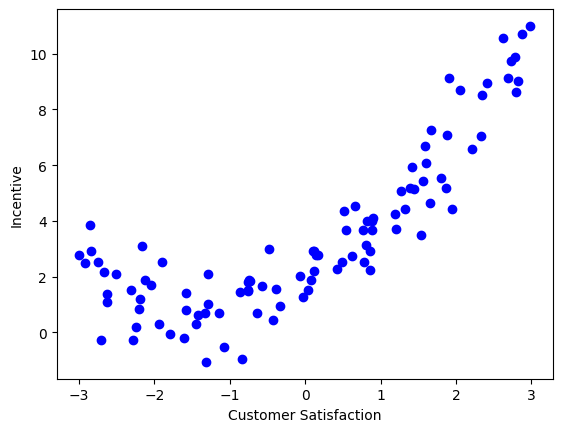

In [9]:
plt.scatter(df["Customer Satisfaction"], df["Incentive"], color="b")
plt.xlabel("Customer Satisfaction")
plt.ylabel("Incentive")
plt.show()

In [10]:
# dependent & independent features
X = df[["Customer Satisfaction"]]
y = df["Incentive"]

In [11]:
X.head()

,Customer Satisfaction
0,-1.282447
1,0.425298
2,1.953070
3,2.625838
4,-1.426333


In [12]:
y.head()

,Incentive
0,1.010513
1,2.281043
2,4.415053
3,10.563600
4,0.627365


In [13]:
#train - test split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 15 )

In [15]:
X_train

,Customer Satisfaction
99,0.512504
3,2.625838
20,-0.865714
55,-1.145369
6,2.823460
...,...
28,1.191020
0,-1.282447
5,-1.311432
12,0.490521


In [16]:
regression = LinearRegression()

In [17]:
#scaler

In [18]:
scaler = StandardScaler()

In [19]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
regression = LinearRegression()

In [21]:
regression.fit(X_train, y_train)

LinearRegression()

In [22]:
## prediction

In [23]:
y_pred = regression.predict(X_test)

In [24]:
y_pred

array([ 4.65663741,  3.71913877,  1.64121789,  6.29646523,  3.46766736,
        5.7580845 ,  4.692485  ,  3.61616231,  5.62448003,  0.13472702,
        4.47909659,  4.8130839 ,  1.58319087,  0.30515983,  5.27634309,
        0.41711005, -0.7385295 , -0.32653914,  3.55906887,  1.19798631])

In [25]:
score = r2_score(y_test, y_pred)
print(score)

0.2705652535622246


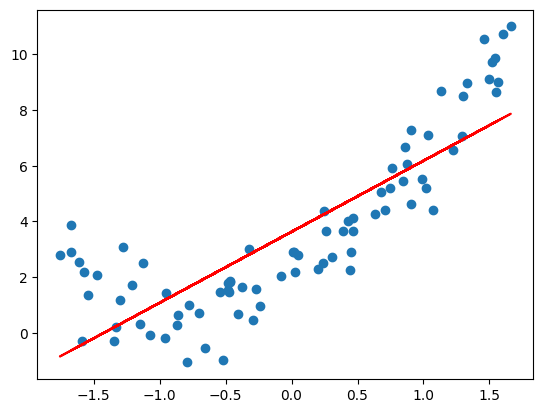

In [26]:
plt.scatter(X_train, y_train)
plt.plot(X_train, regression.predict(X_train), color = "r")
plt.show()

In [27]:
poly = PolynomialFeatures(degree = 2, include_bias = True)

In [28]:
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [29]:
X_train_poly

array([[ 1.00000000e+00,  2.47633535e-01,  6.13223675e-02],
       [ 1.00000000e+00,  1.45565669e+00,  2.11893639e+00],
       [ 1.00000000e+00, -5.40182671e-01,  2.91797318e-01],
       [ 1.00000000e+00, -7.00039198e-01,  4.90054879e-01],
       [ 1.00000000e+00,  1.56862116e+00,  2.46057233e+00],
       [ 1.00000000e+00,  9.87568378e-01,  9.75291302e-01],
       [ 1.00000000e+00,  4.48640749e-01,  2.01278522e-01],
       [ 1.00000000e+00,  1.54377517e+00,  2.38324178e+00],
       [ 1.00000000e+00,  1.33219938e+00,  1.77475518e+00],
       [ 1.00000000e+00, -4.80410926e-01,  2.30794658e-01],
       [ 1.00000000e+00,  3.92892957e-01,  1.54364876e-01],
       [ 1.00000000e+00, -6.57456685e-01,  4.32249293e-01],
       [ 1.00000000e+00,  4.42663768e-01,  1.95951211e-01],
       [ 1.00000000e+00, -8.72131603e-01,  7.60613533e-01],
       [ 1.00000000e+00, -1.57257044e+00,  2.47297780e+00],
       [ 1.00000000e+00, -4.70184630e-01,  2.21073587e-01],
       [ 1.00000000e+00, -8.36083500e-02

In [30]:
regression = LinearRegression()
regression.fit(X_train_poly, y_train)

LinearRegression()

In [31]:
y_pred = regression.predict(X_test_poly)
score = r2_score(y_test, y_pred)
print(score)

0.7685687698788557


In [32]:
regression.coef_

array([0.        , 2.63871762, 1.54959954])

In [33]:
regression.intercept_

np.float64(2.076676429793281)

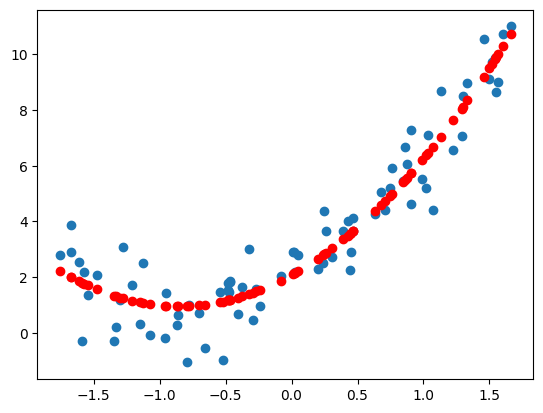

In [34]:
plt.scatter(X_train, y_train)
plt.scatter(X_train, regression.predict(X_train_poly), color = "r")
plt.show()

In [35]:
poly = PolynomialFeatures(degree = 3, include_bias = True)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [36]:
regression = LinearRegression()
regression.fit(X_train_poly, y_train)
y_pred = regression.predict(X_test_poly)
score = r2_score(y_test, y_pred)
print(score)


0.757344362140105


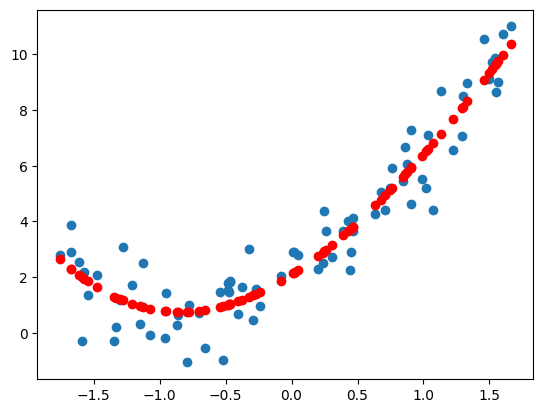

In [37]:
plt.scatter(X_train, y_train)
plt.scatter(X_train, regression.predict(X_train_poly), color = "r")
plt.show()

In [38]:
# new data

In [39]:
new_df = pd.read_csv("3-newdatas.csv")

In [40]:
new_df

,0
0,-3.000000
1,-2.969849
2,-2.939698
3,-2.909548
4,-2.879397
...,...
195,2.879397
196,2.909548
197,2.939698
198,2.969849


In [41]:
new_df.rename(columns = {"0": "Customer Satisfaction"}, inplace=True )

In [42]:
new_df

,Customer Satisfaction
0,-3.000000
1,-2.969849
2,-2.939698
3,-2.909548
4,-2.879397
...,...
195,2.879397
196,2.909548
197,2.939698
198,2.969849


In [43]:
X_new = new_df[["Customer Satisfaction"]]

In [44]:
new_df

,Customer Satisfaction
0,-3.000000
1,-2.969849
2,-2.939698
3,-2.909548
4,-2.879397
...,...
195,2.879397
196,2.909548
197,2.939698
198,2.969849


In [45]:
scaler.fit_transform(X_new)

array([[-1.7234121 ],
       [-1.70609137],
       [-1.68877065],
       [-1.67144992],
       [-1.6541292 ],
       [-1.63680847],
       [-1.61948775],
       [-1.60216702],
       [-1.5848463 ],
       [-1.56752558],
       [-1.55020485],
       [-1.53288413],
       [-1.5155634 ],
       [-1.49824268],
       [-1.48092195],
       [-1.46360123],
       [-1.4462805 ],
       [-1.42895978],
       [-1.41163905],
       [-1.39431833],
       [-1.3769976 ],
       [-1.35967688],
       [-1.34235616],
       [-1.32503543],
       [-1.30771471],
       [-1.29039398],
       [-1.27307326],
       [-1.25575253],
       [-1.23843181],
       [-1.22111108],
       [-1.20379036],
       [-1.18646963],
       [-1.16914891],
       [-1.15182818],
       [-1.13450746],
       [-1.11718674],
       [-1.09986601],
       [-1.08254529],
       [-1.06522456],
       [-1.04790384],
       [-1.03058311],
       [-1.01326239],
       [-0.99594166],
       [-0.97862094],
       [-0.96130021],
       [-0

In [46]:
X_new_poly = poly.transform(X_new)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but PolynomialFeatures was fitted without feature names
  warnings.warn(


In [49]:
y_new = regression.predict(X_new_poly)

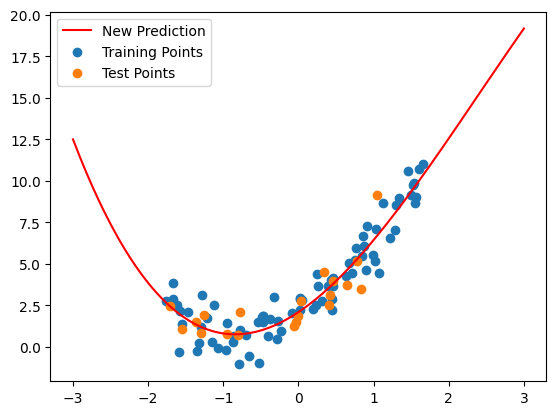

In [51]:
plt.plot(X_new, y_new, "r", label="New Prediction")
plt.scatter(X_train, y_train, label="Training Points")
plt.scatter(X_test, y_test, label="Test Points")
plt.legend()
plt.show()

In [ ]:
#pipeline

In [60]:
def poly_regression(degree):
  poly_features = PolynomialFeatures(degree=degree)
  lin_reg = LinearRegression()
  pipeline = Pipeline([
      ("standard scaler", scaler),
      ("poly_fetures", poly_features),
      ("lin_reg", lin_reg)
  ])
  pipeline.fit(X_train, y_train)
  score = pipeline.score(X_test, y_test)
  print("R2 score:", score)

  y_pred_new = pipeline.predict(X_new)
  plt.plot(X_new, y_pred_new, "r", label="New Prediction")
  plt.scatter(X_train, y_train, label="Training Points")
  plt.scatter(X_test, y_test, label="Test Points")
  plt.legend()
  plt.show()

R2 score: 0.2705652535622246


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


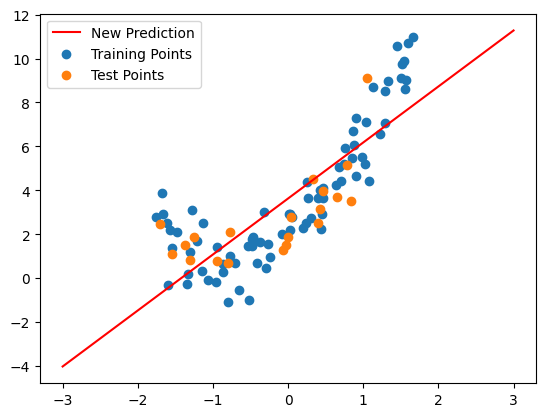

R2 score: 0.7685687698788557


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


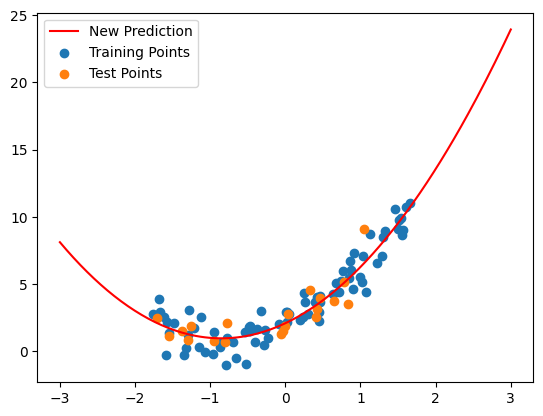

R2 score: 0.7573443621401048


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


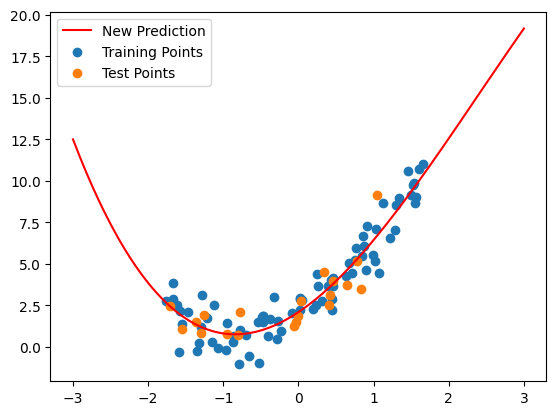

R2 score: 0.7355034443260413


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


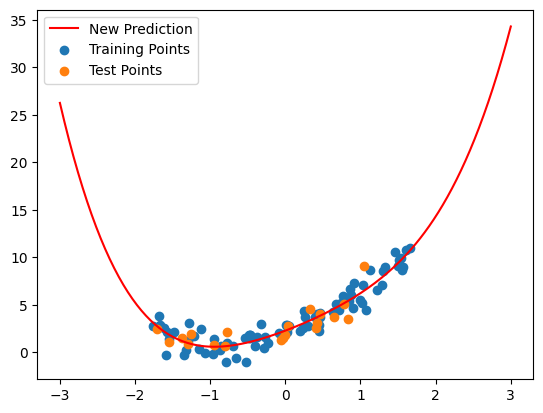

R2 score: 0.73512441650954


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


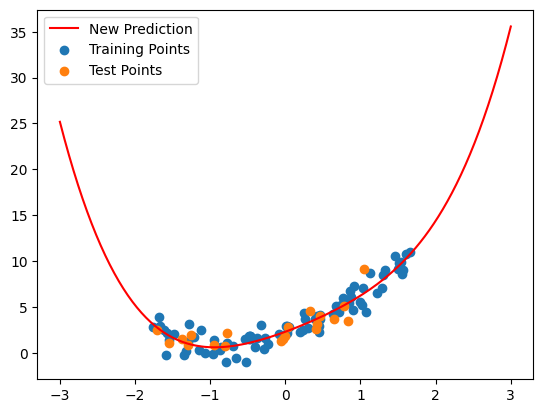

R2 score: 0.7343590482133435


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


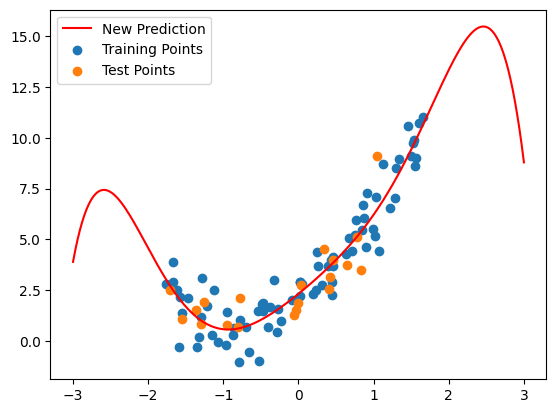

R2 score: 0.7347819263549452


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


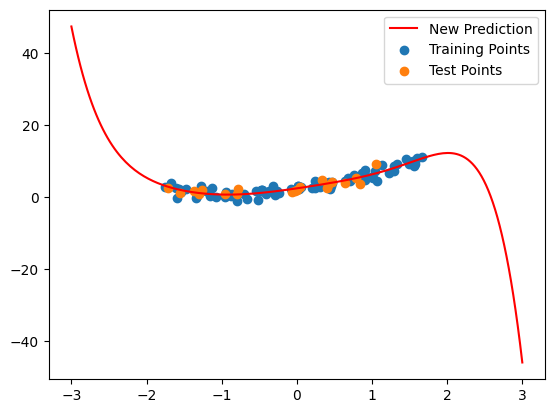

R2 score: 0.7411422099998375


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


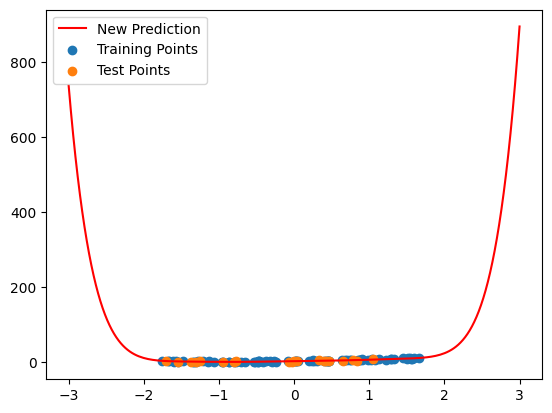

R2 score: 0.7310763879815911


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


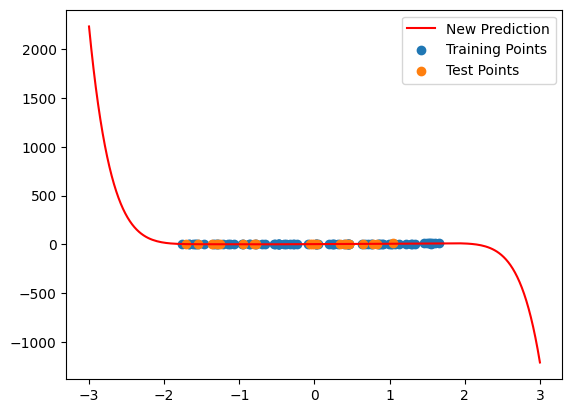

R2 score: 0.7280578621232836


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


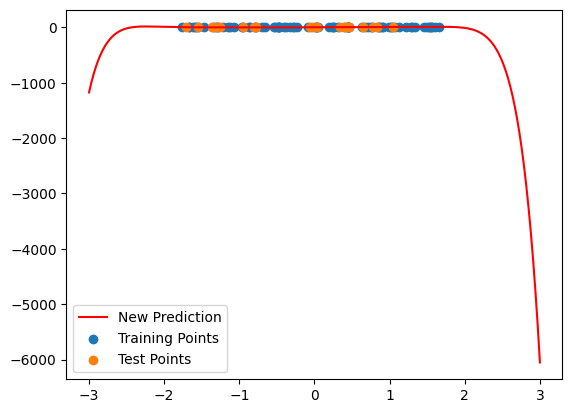

In [61]:
for degree in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]:
  poly_regression(degree)
